# Neural Models: XOR, Backpropagation, Activations, and Output Layers

The four sensor inputs implement XOR: `(0,0)->0`, `(0,1)->1`, `(1,0)->1`,
`(1,1)->0`. A single affine decision boundary cannot separate the diagonal positive
points from both negative points, so the model uses the required 2-2-1 architecture
with a nonlinear hidden layer. Binary output training uses logits with
`BCEWithLogitsLoss`, the numerically stable sigmoid/BCE pairing.

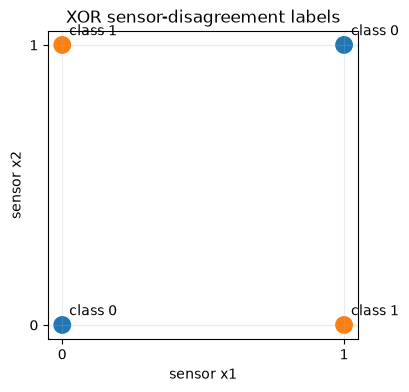

In [1]:
import copy
import math
import matplotlib.pyplot as plt
import torch
from torch import nn

torch.set_num_threads(1)
torch.set_printoptions(precision=6, sci_mode=False)

X = torch.tensor(
    [[0.0, 0.0], [0.0, 1.0], [1.0, 0.0], [1.0, 1.0]],
    dtype=torch.float32,
)
y_binary = torch.tensor([[0.0], [1.0], [1.0], [0.0]], dtype=torch.float32)

colours = ["tab:blue" if label == 0 else "tab:orange" for label in y_binary.flatten()]
plt.figure(figsize=(4, 4))
plt.scatter(X[:, 0], X[:, 1], c=colours, s=140)
for point, label in zip(X, y_binary.flatten()):
    plt.annotate(f"class {int(label.item())}", point.tolist(), xytext=(5, 7), textcoords="offset points")
plt.xticks([0, 1]); plt.yticks([0, 1])
plt.xlabel("sensor x1"); plt.ylabel("sensor x2")
plt.title("XOR sensor-disagreement labels")
plt.grid(alpha=0.25)
plt.show()

## 2-2-1 binary XOR network and backpropagation evidence

In [2]:
ACTIVATIONS = {
    "sigmoid": nn.Sigmoid,
    "tanh": nn.Tanh,
    "relu": nn.ReLU,
}


class XORNet(nn.Module):
    def __init__(self, hidden_activation="tanh"):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.activation = ACTIVATIONS[hidden_activation]()
        self.fc2 = nn.Linear(2, 1)  # one binary logit

    def forward(self, inputs):
        hidden = self.activation(self.fc1(inputs))
        return self.fc2(hidden)


def train_xor(activation="tanh", seed=2, steps=3000, learning_rate=0.05):
    torch.manual_seed(seed)
    model = XORNet(activation)
    loss_fn = nn.BCEWithLogitsLoss()
    optimiser = torch.optim.Adam(model.parameters(), lr=learning_rate)
    with torch.no_grad():
        initial_loss = loss_fn(model(X), y_binary).item()

    early_gradient_norm = None
    for step in range(steps):
        optimiser.zero_grad()
        logits = model(X)                 # forward pass
        loss = loss_fn(logits, y_binary)  # scalar mean loss
        loss.backward()                   # reverse-mode automatic differentiation
        if step == 10:
            early_gradient_norm = model.fc1.weight.grad.norm().item()
        optimiser.step()                  # parameter update

    # Recompute a final gradient so parameter.grad matches the final parameters.
    optimiser.zero_grad()
    final_logits = model(X)
    final_loss = loss_fn(final_logits, y_binary)
    final_loss.backward()
    probabilities = torch.sigmoid(final_logits).detach().flatten()
    predictions = (probabilities >= 0.5).to(torch.int64)
    return {
        "model": model,
        "initial_loss": initial_loss,
        "final_loss": final_loss.item(),
        "probabilities": probabilities,
        "predictions": predictions,
        "early_gradient_norm": early_gradient_norm,
        "final_first_layer_gradient": model.fc1.weight.grad.detach().clone(),
    }


binary_result = train_xor("tanh")
print("Initial loss:", binary_result["initial_loss"])
print("Final loss:", binary_result["final_loss"])
print("Probabilities:", binary_result["probabilities"])
print("Thresholded predictions:", binary_result["predictions"])
print("First-layer gradient after final backward():\n", binary_result["final_first_layer_gradient"])

expected_binary = y_binary.flatten().to(torch.int64)
assert torch.equal(binary_result["predictions"], expected_binary)
assert binary_result["final_loss"] < 0.01

Initial loss: 0.6932286024093628
Final loss: 9.038134157890454e-05
Probabilities: tensor([0.000070, 0.999901, 0.999876, 0.000068])
Thresholded predictions: tensor([0, 1, 1, 0])
First-layer gradient after final backward():
 tensor([[-0.000004,  0.000004],
        [-0.000005,  0.000005]])


`parameter.grad` stores the derivative of the scalar loss with respect to that
parameter, here $\partial L / \partial W^{(1)}$. Because `BCEWithLogitsLoss` uses
mean reduction by default, this tensor is the average of the four example-wise
gradients. Its usefulness is validated by the large loss reduction and 4/4 correct
predictions, not merely by being nonzero.

## Zero-initialisation symmetry experiment

In [3]:
def zero_initialisation_experiment(steps=500):
    model = XORNet("tanh")
    with torch.no_grad():
        for parameter in model.parameters():
            parameter.zero_()
    optimiser = torch.optim.Adam(model.parameters(), lr=0.05)
    loss_fn = nn.BCEWithLogitsLoss()
    snapshots = {}

    for step in range(steps + 1):
        optimiser.zero_grad()
        loss = loss_fn(model(X), y_binary)
        loss.backward()
        if step in {0, 1, 10, 100, 500}:
            snapshots[step] = model.fc1.weight.detach().clone()
        if step < steps:
            optimiser.step()
    return model, loss.item(), snapshots


zero_model, zero_loss, symmetry_snapshots = zero_initialisation_experiment()
for step, weights in symmetry_snapshots.items():
    print(f"Step {step} hidden weights:\n{weights}")
    assert torch.allclose(weights[0], weights[1])

zero_probabilities = torch.sigmoid(zero_model(X)).detach().flatten()
print("Final zero-initialised loss:", zero_loss)
print("Final probabilities:", zero_probabilities)
print("The hidden rows remain identical, so the hidden units cannot learn distinct features.")

Step 0 hidden weights:
tensor([[0., 0.],
        [0., 0.]])
Step 1 hidden weights:
tensor([[0., 0.],
        [0., 0.]])
Step 10 hidden weights:
tensor([[0., 0.],
        [0., 0.]])
Step 100 hidden weights:
tensor([[0., 0.],
        [0., 0.]])
Step 500 hidden weights:
tensor([[0., 0.],
        [0., 0.]])
Final zero-initialised loss: 0.6931471824645996
Final probabilities: tensor([0.500000, 0.500000, 0.500000, 0.500000])
The hidden rows remain identical, so the hidden units cannot learn distinct features.


## Activation experiment with identical seed and training settings

In [4]:
activation_results = []
for activation in ("sigmoid", "tanh", "relu"):
    result = train_xor(activation=activation, seed=2, steps=3000, learning_rate=0.05)
    correct = int(torch.equal(result["predictions"], expected_binary))
    activation_results.append(
        (activation, result["final_loss"], correct, result["early_gradient_norm"])
    )

print(f"{'Activation':<12} {'Final loss':<14} {'4/4 correct?':<15} {'Early ||grad W1||'}")
for activation, loss, correct, gradient_norm in activation_results:
    print(f"{activation:<12} {loss:<14.8f} {str(bool(correct)):<15} {gradient_norm:.8f}")

assert all(row[2] for row in activation_results)
print("\nAll three activations solve this seeded tiny experiment; the gradient scales differ.")

Activation   Final loss     4/4 correct?    Early ||grad W1||
sigmoid      0.00025914     True            0.00105040
tanh         0.00009038     True            0.02165898
relu         0.00003288     True            0.00681789

All three activations solve this seeded tiny experiment; the gradient scales differ.


## Three-class extension with three logits and cross-entropy

In [5]:
y_three_class = torch.tensor([0, 1, 1, 2], dtype=torch.long)


class ThreeClassNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 2)
        self.fc2 = nn.Linear(2, 3)  # weight shape: [3, 2]; three logits/example

    def forward(self, inputs):
        return self.fc2(torch.tanh(self.fc1(inputs)))


torch.manual_seed(0)
three_class_model = ThreeClassNet()
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(three_class_model.parameters(), lr=0.05)

for _ in range(4000):
    optimiser.zero_grad()
    logits = three_class_model(X)
    loss = loss_fn(logits, y_three_class)
    loss.backward()
    optimiser.step()

with torch.no_grad():
    logits = three_class_model(X)
    probabilities = torch.softmax(logits, dim=1)
    predictions = probabilities.argmax(dim=1)

print("Final output-weight shape:", tuple(three_class_model.fc2.weight.shape))
print("Final loss:", loss.item())
for inputs, probability, prediction in zip(X, probabilities, predictions):
    print(
        f"Input {tuple(int(v) for v in inputs.tolist())}: "
        f"probabilities={probability.tolist()}, predicted class={prediction.item()}"
    )

probability_sum = probabilities[0].sum().item()
print("First probability-vector sum:", probability_sum)
assert torch.equal(predictions, y_three_class)
assert abs(probability_sum - 1.0) < 1e-6

Final output-weight shape: (3, 2)
Final loss: 1.9848139345413074e-05
Input (0, 0): probabilities=[0.9999748468399048, 2.5167702915496193e-05, 3.543025872687622e-09], predicted class=0
Input (0, 1): probabilities=[1.2015927495667711e-05, 0.9999842643737793, 3.6510250538412947e-06], predicted class=1
Input (1, 0): probabilities=[1.1895778698089998e-05, 0.999984622001648, 3.4419620078551816e-06], predicted class=1
Input (1, 1): probabilities=[1.3445310287352186e-07, 2.300876622030046e-05, 0.9999768733978271], predicted class=2
First probability-vector sum: 1.0


## Softmax invariance and the p-y logit gradient

In [6]:
shifted_probabilities = torch.softmax(logits + 100.0, dim=1)
max_shift_difference = (probabilities - shifted_probabilities).abs().max().item()
print("Maximum change after adding 100 to every logit:", max_shift_difference)
assert torch.allclose(probabilities, shifted_probabilities, atol=1e-6)

# For one example (no batch averaging), d cross_entropy / d logits = p - one_hot(y).
one_logits = logits[0].detach().clone().requires_grad_(True)
one_target = y_three_class[0].view(1)
one_loss = nn.functional.cross_entropy(one_logits.view(1, -1), one_target)
one_loss.backward()
one_hot = nn.functional.one_hot(one_target, num_classes=3).float().squeeze(0)
expected_gradient = torch.softmax(one_logits.detach(), dim=0) - one_hot

print("Autograd logit gradient:", one_logits.grad)
print("p - y:", expected_gradient)
assert torch.allclose(one_logits.grad, expected_gradient, atol=1e-6)
print("Softmax invariance and p-y gradient checks passed.")

Maximum change after adding 100 to every logit: 9.640643838793039e-11
Autograd logit gradient: tensor([-0.000025,  0.000025,  0.000000])
p - y: tensor([-0.000025,  0.000025,  0.000000])
Softmax invariance and p-y gradient checks passed.
